# 03 · Revenue Forecasting (Model A)
Trains and compares Linear Regression, Random Forest, and XGBoost on the full feature set. The official, full-scale (150k-row) results used in the dashboard are produced by `src/regression.py`; this notebook re-runs the same code path so the methodology is inspectable end to end.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd, json
from regression import train_and_evaluate
df = pd.read_csv('../data/adcore_features.csv', parse_dates=['timestamp'])
df.shape

(150000, 42)

In [2]:
results, models = train_and_evaluate(df)
pd.DataFrame(results['comparison']).T

,MAE,RMSE,MAPE,R2
Linear Regression,0.5148,2.0571,650.90,0.8018
Random Forest,0.3062,1.7374,22.75,0.8587
XGBoost,0.3181,1.7662,48.27,0.8539


## Why the best model wins

In [3]:
print('Best model:', results['best_model'])
print()
print(results['explanation'])

Best model: Random Forest

Random Forest wins on MAE/RMSE because it captures non-linear interactions between engagement, device, and campaign features that a purely linear model cannot represent, while controlling variance better than a single-tree model would. We select on MAE (not just R^2) because revenue is right-skewed and MAE is more robust to the few very large spend campaigns, giving a truer picture of typical forecast error.


## Visual comparison

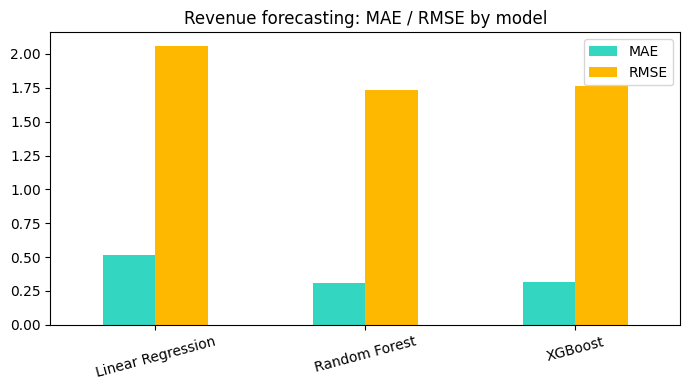

In [4]:
import matplotlib.pyplot as plt
comp = pd.DataFrame(results['comparison']).T
fig, ax = plt.subplots(figsize=(7,4))
comp[['MAE','RMSE']].plot(kind='bar', ax=ax, color=['#33D6C0','#FFB800'])
ax.set_title('Revenue forecasting: MAE / RMSE by model')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()